In [1]:
import numpy as np
import matplotlib.pyplot as plt
eps = np.finfo(float).eps

## Notes:
<b> Vanilla Gradient Descent</b> uses a fixed step size
\
<b> Gradient Descent with Exact Line Search</b> determines optimal step size to minimized objective function


# Task:
Implement vanilla gradient descent, gradient descent with exact line search, and Nesterov’s
accelerated gradient for a strongly convex quadratic. Plot convergence (log error vs. itera-
tion) for all three on the same semilogy plot.

## Definitions

A strongly convex quadratic function is $$f(X) = \frac{1}{2} x^T Ax - b^T x$$
The gradient is $$\nabla f(x) = Ax - b$$
And the optimal step size $\alpha$ that is the value which minimizes $f(x-a\nabla f(x))$
$$\text{argmin} f(x - \alpha \nabla f(x))$$
$$\alpha_k = \frac{|| - \nabla f(x_k) ||^2} {(-\nabla f(x_k)^T A (-\nabla f(x_k)))}$$

Nesterov's Gradient
$w$ is weight, $\beta$ is momentum and $v_{t-1}$ is previous velocity term, $\eta$ is learning rate.
\
Calculate Look Ahead Point
$$w_{\text{look ahead}} = w - \beta * v_{t-1}$$
Calculate Gradient at Look Ahead
$$\text{Gradient} = \nabla f(w_{\text{look-ahead}})$$
Update Velocity Term
$$v_t = \beta*v_{t-1} + \eta *\text{gradient}$$
Update Weights
$$w = w - v_t$$
Nesterov reduces oscillations around minimum, and often reaches convergence faster

[[-0.02514119  0.01792666]]


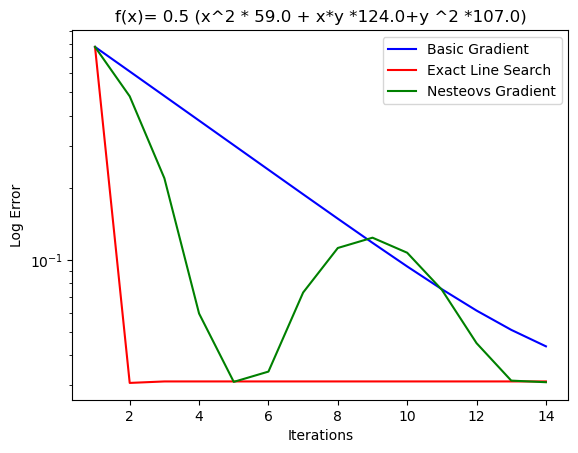

In [27]:
def f(xV, yV):
    x = np.array([xV, yV])
    quadTerm = 0.5 * (xV**2 * A[0,0] + xV*yV *(A[0,1]+A[1,0])+yV **2 *A[1,1])
    other = b[0]*xV + b[1]*yV
    return quadTerm - other
def Basic_Gradient(A, b, start, learningRate, iterations):
    x = start
    errors = []
    for i in iterations:
        gradient = A @ x - b
        x = x - learningRate * gradient
        approxValue = np.array([f(x[0],x[1])])
        error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(error_vector)) #l2 norm
    return x, errors
def gradient_with_ExactLine(A, b, start, iterations):
    x = start.copy()
    errors = []
    for i in iterations:
        gradient = A @ x -b
        #check for convergence using norm of the gradient 
        if np.linalg.norm(gradient) < tol:
            print(f"Converged")
            #return x
        numerator = (gradient @ gradient) 
        denominator = (gradient.T) @ A @ gradient 
        alpha = numerator/denominator
        x = x- alpha * gradient
        approxValue = np.array([f(x[0],x[1])])
        error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(error_vector)) 
    return x, errors
def nesterovs_gradient(A, b, start, learningRate, momentum, iterations):
    x = start.copy()
    velocity = np.zeros_like(start)
    errors = []
    for i in iterations:
        lookAhead = x+momentum * velocity
        gradient = A@ lookAhead - b 
        velocityNew = momentum * velocity - learningRate * gradient 
        x += velocityNew
        approxValue = np.array([f(x[0],x[1])])
        error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(error_vector)) 
        velocity = velocityNew
    return x, errors

""" define the values for the function """
A = np.random.randint(1, 10, size=(2,2)) #low, high
A = A.T @ A + np.eye(2)
b = np.random.randn(2)
x_initial = np.ones(2)
tol = eps

L = np.max(np.linalg.eigvals(A))
learningRate = 1/L #Lipschitz constant 
iterations = np.arange(1,15,1)
exact = np.array([np.linalg.solve(A,b)])
print(exact)
xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations)
xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations)
xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, 0.9, iterations)
plt.title(f"f(x)= 0.5 (x^2 * {A[0,0]} + x*y *{(A[0,1]+A[1,0])}+y ^2 *{A[1,1]})")

plt.semilogy(iterations, errorsBG, 'b-', iterations, errorsGE, 'r-', iterations, errorsNG, 'g-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
plt.show();

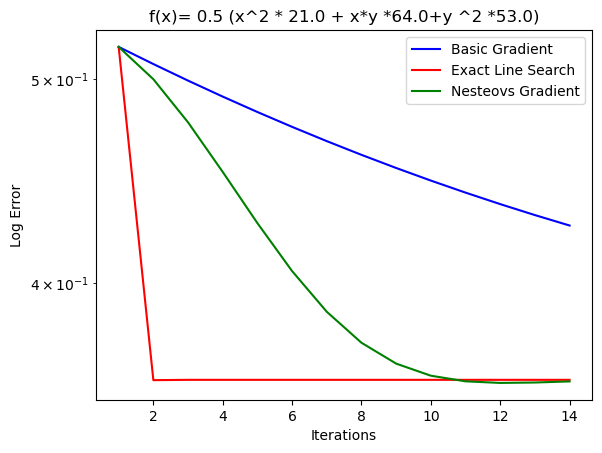

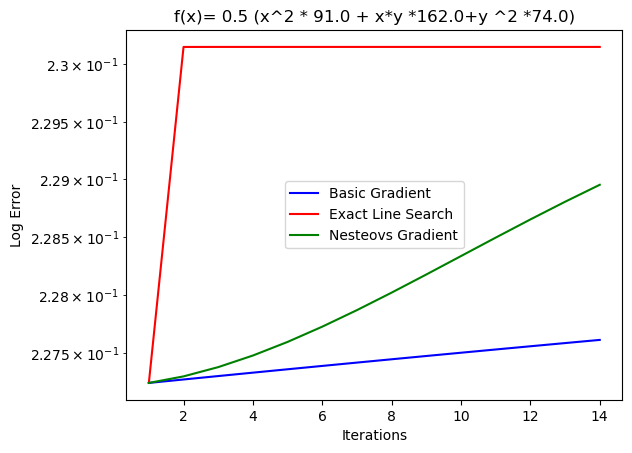

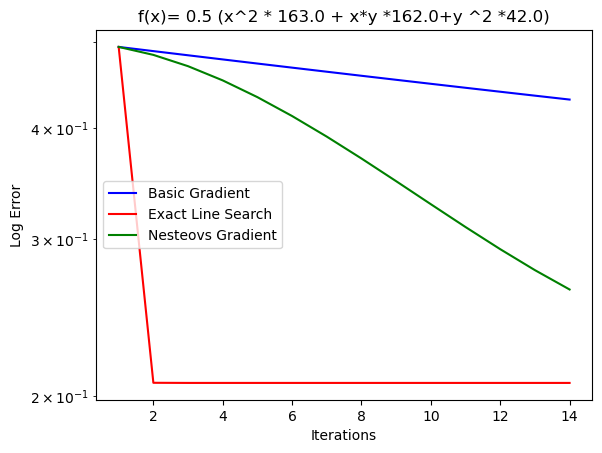

In [25]:
for j in range(3):
    A = np.random.randint(1, 10, size=(2,2)) #low, high
    A = A.T @ A + np.eye(2)
    b = np.random.randn(2)
    x_initial = np.ones(2)
    tol = eps
    
    L = np.max(np.linalg.eigvals(A))
    learningRate = 1/L #Lipschitz constant 
    iterations = np.arange(1,15,1)
    exact = np.array([np.linalg.solve(A,b)])
    
    xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations)
    xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations)
    xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, 0.9, iterations)
    plt.semilogy(iterations, errorsBG, 'b-', iterations, errorsGE, 'r-', iterations, errorsNG, 'g-')
    plt.title(f"f(x)= 0.5 (x^2 * {A[0,0]} + x*y *{(A[0,1]+A[1,0])}+y ^2 *{A[1,1]})")
    plt.xlabel('Iterations')
    plt.ylabel('Log Error')
    plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])
    plt.show();

#
118.  63.]
 [ 63.  46.]]
B = [0.58470757 0.95023374

[[-0.02259642  0.05160453]]


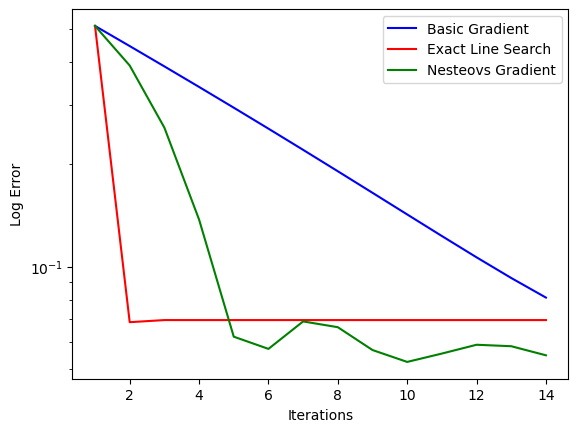

In [22]:
A = np.array([[118,63],[63,46]])
b=np.array([0.58470757, 0.95023374])
x_initial = np.ones(2)
tol = eps
L = np.max(np.linalg.eigvals(A))
learningRate = 1/L #Lipschitz constant 
iterations = np.arange(1,15,1)
exact = np.array([np.linalg.solve(A,b)])
print(exact)
xBG, errorsBG = Basic_Gradient(A, b, x_initial, learningRate, iterations)
xGE, errorsGE = gradient_with_ExactLine(A, b, x_initial, iterations)
xNG, errorsNG = nesterovs_gradient(A, b, x_initial, learningRate, 0.9, iterations)
plt.semilogy(iterations, errorsBG, 'b-', iterations, errorsGE, 'r-', iterations, errorsNG, 'g-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.legend(['Basic Gradient', 'Exact Line Search', 'Nesteovs Gradient'])

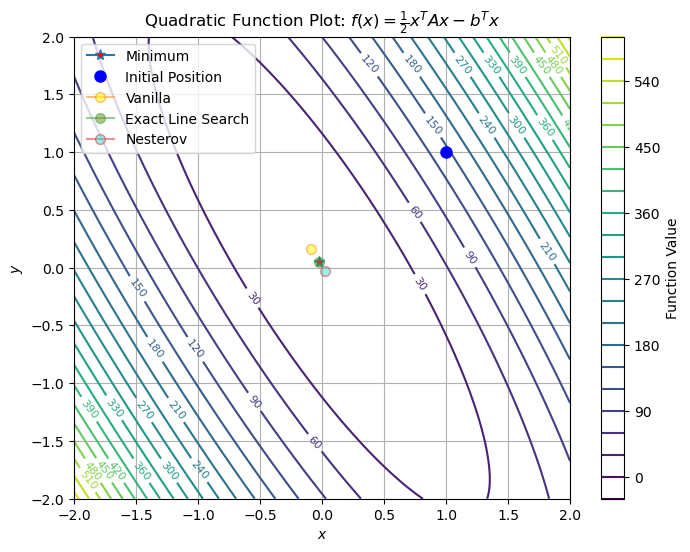

In [4]:
xV = np.linspace(-2, 2, 100)
yV = np.linspace(-2,2,100)
X, Y = np.meshgrid(xV, yV)
Z = f(X, Y)
plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
min_x = np.linalg.solve(A,b)
exact = np.linalg.solve(A,b)
plt.plot(min_x[0], min_x[1], marker = '*', markerfacecolor='red', markersize=8, label='Minimum')
plt.plot(x_initial[0], x_initial[1], 'bo', markersize=8, label='Initial Position')
plt.plot(xBG[0], xBG[1], marker='o', markerfacecolor='yellow',alpha=0.5, markersize = 7, label='Vanilla')
plt.plot(xGE[0], xGE[1],marker='o', markerfacecolor='olivedrab',alpha=0.5, markersize=7, label='Exact Line Search')
plt.plot(xNG[0], xNG[1], marker='o',markerfacecolor='turquoise',alpha=0.5, markersize=7, label='Nesterov')
plt.title('Quadratic Function Plot: $f(x) = \\frac{1}{2} x^T Ax - b^T x$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.colorbar(contour, label='Function Value')
plt.legend()
plt.grid(True)
plt.show()

# Task 1B: Visualizing the Path of Gradient Descent

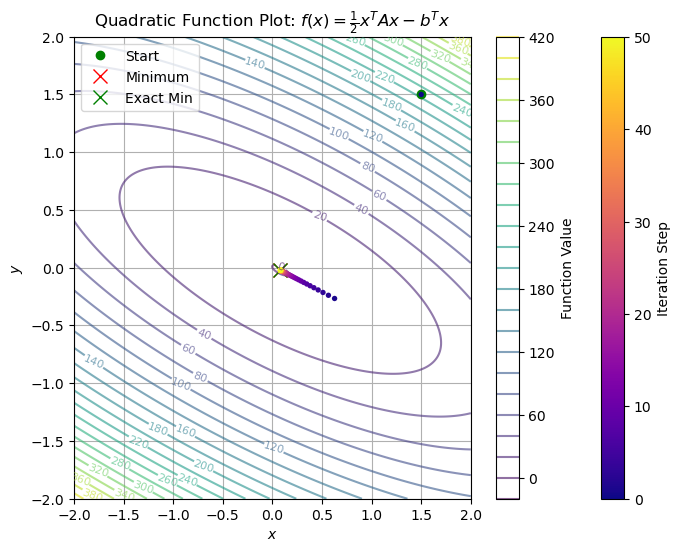

In [5]:
# Av= np.array([[51,18],[18,21]])
# bv = np.array([-1.98468569, 0.54850085])

Av = np.random.randint(1, 10, size=(2,2)) #low, high
Av = Av.T @ Av + np.eye(2)
bv = np.random.randn(2)
def f(x, y, A, b):
    return 0.5 * (A[0,0]*x**2 + (A[0,1] + A[1,0])*x*y + A[1,1]*y**2) - (b[0]*x + b[1]*y)
def visualizeGradientVanilla(A, b, start, learningRate, iterations):
    x = start.astype(float)
    xPoints = [x.copy()]
    errors = []
    for i in iterations:
        gradient = A @ x - b
        x = x - learningRate * gradient
        approxValue = np.array([f(x[0],x[1], A, b)])
        error_vector = np.abs(exact - approxValue)
        errors.append(np.linalg.norm(error_vector)) #l2 norm
        point = x
        xPoints.append(x.copy())
    return x, np.array(xPoints), errors

#plotting Function
xV = np.linspace(-2, 2, 400)
yV = np.linspace(-2,2,400)
X, Y = np.meshgrid(xV, yV)
Z = f(X, Y, Av, bv)
exact = np.linalg.solve(Av, bv)

plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, Z,levels=20, cmap='viridis', alpha = 0.6)
plt.clabel(contour, inline = True, fontsize=8)
plt.title('Quadratic Function Plot: $f(x) = \\frac{1}{2} x^T Ax - b^T x$')
plt.xlabel('$x$')
plt.ylabel('$y$')

#finding path 
start = np.array([1.5, 1.5])
its = range(50)
L = np.max(np.linalg.eigvals(Av))
learningRate = 1/L 
final, path, errs = visualizeGradientVanilla(Av, bv, start, learningRate, its)
path = np.array(path)
#back to plotting
step_indices = np.arange(len(path))

scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=15, edgecolors='none', zorder=3)
cbar = plt.colorbar(scatter)
cbar.set_label('Iteration Step')
plt.plot(path[0, 0], path[0,1], 'go', label='Start')
plt.plot(final[0], final[1], 'rx', markersize=10, label='Minimum')
plt.plot(exact[0], exact[1], 'gx', markersize=10, label='Exact Min')
plt.legend()
plt.colorbar(contour, label='Function Value')
plt.grid(True)
plt.show()

# Task #2 Minimizing a Non Convex Test Function

Rosenbrock's Banana Function is: 
$$f(x,y)= (a - x)^2 + b (y-x^2)^2$$
It has a global minimum at $(x, y) = (a, a^2)$, where $f(x, y) = 0$. The gradient of Rosenbrock's Banana is 
$$\frac{\partial f}{\partial x} = -2a + 4bx(x^2 - y)+2x$$
$$\frac{\partial f}{\partial y} = 2b (-x^2 +y)$$ 
Since,
$$\nabla f = (\frac{\partial f}{\partial x} \frac{\partial f}{\partial y})$$ 
$$\nabla f =  \left(-2a + 4bx(x^2 - y)+2x, 2b (-x^2 +y) \right)$$

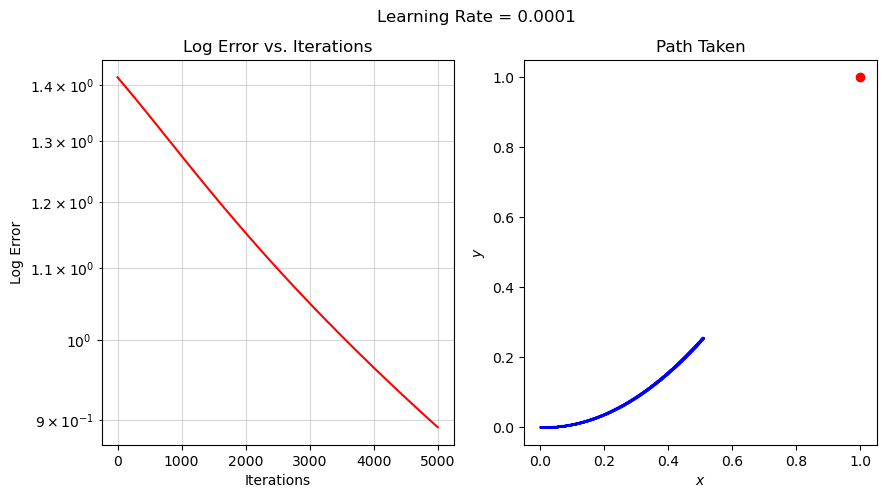

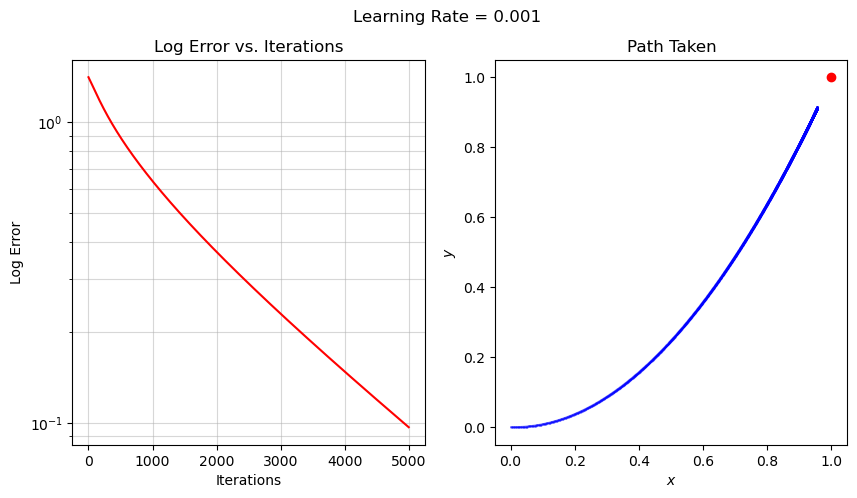

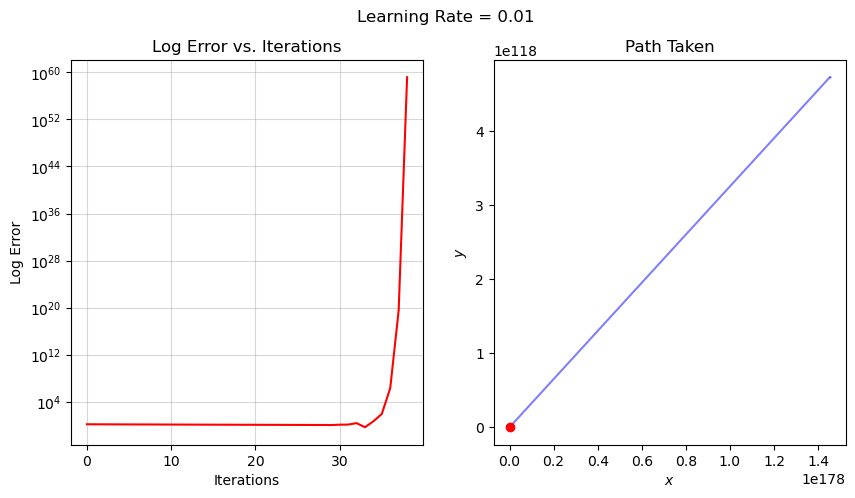

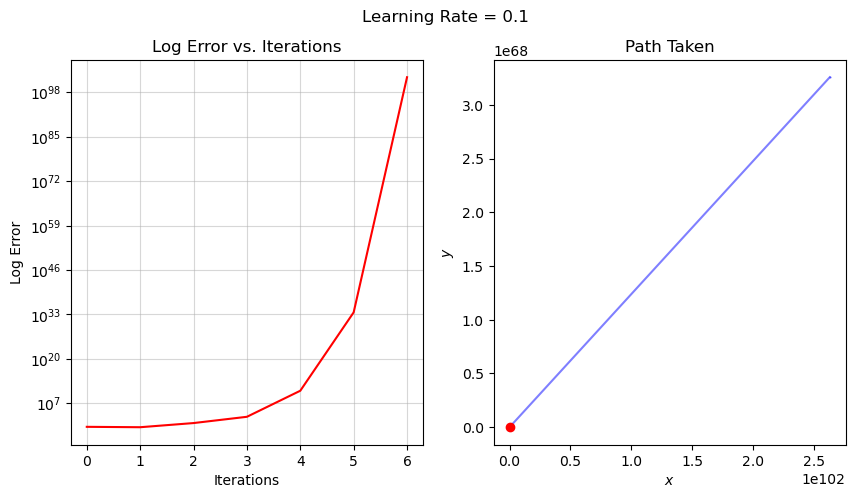

In [6]:
tol = eps
def Rosenbrock(x, y, a = 1, b = 100):
    value = (a-x)**2 + b*(y-x**2)**2
    return value
def gradientRosenbrock(x,y, a = 1, b = 100):
    df_dx = -2*a + 4*b*x*(x**2 - y) + 2*x
    df_dy = 2 * b * (-x**2 + y)
    return np.array([df_dx, df_dy])
def function_basic_gradient(func, grad, exact, start, learningRate, iterations):
    x = np.array(start)
    errors = []
    history = []
    for i in iterations:
        gradient = grad(x[0],x[1])
        x = x - learningRate * gradient
        error = np.linalg.norm(x - exact)
        errors.append(error) #l2 norm
        history.append(x.copy())
    return x, errors, history
a = 1
exact = np.array([a, a**2])
lr = 0.002
iterations = range(1,5000)
v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)

lrs = [0.0001, 0.001, 0.01, 0.1]
#plotting 
import warnings
warnings.filterwarnings('ignore')
for lr in lrs:
    iterations = range(1,5000)
    v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)
    plt.figure(figsize=(10,5))
    plt.suptitle(f"Learning Rate = {lr}")
    plt.subplot(1,2,1)
    plt.semilogy(range(len(errors)), errors, 'r-')
    plt.xlabel('Iterations')
    plt.ylabel('Log Error')
    plt.title('Log Error vs. Iterations')
    plt.grid(True, which="both", ls="-", alpha = 0.5)
    path = np.array(path)
    plt.subplot(1,2,2)
    plt.plot(path[:,0], path[:,1], 'b.-', markersize=1, alpha = 0.5)
    plt.plot(a, a**2, 'ro') #minimum
    plt.title('Path Taken')
    plt.xlabel('$x$')
    plt.ylabel('$y$')
    plt.show();

In [7]:
# Plot every 50th step to see progression clearly
sub_path = path[::50] 
sub_indices = np.arange(len(path))[::50]

ax_path.quiver(sub_path[:-1, 0], sub_path[:-1, 1], 
               sub_path[1:, 0]-sub_path[:-1, 0], 
               sub_path[1:, 1]-sub_path[:-1, 1], 
               scale_units='xy', angles='xy', scale=1, color='blue', alpha=0.5)

NameError: name 'ax_path' is not defined

In [ ]:
exact = np.array([a, a**2])
lr = 0.001

v, errors, path = function_basic_gradient(Rosenbrock, gradientRosenbrock, exact, [0,0], lr, iterations)
path = np.array(path)

#colorbar to show time
step_indices = np.arange(len(path))
plt.figure(figsize=(10,7))

#Contours Rosenbrock
levels = np.logspace(-1,3,20)
x = np.linspace(-2, 2, 100)
y = np.linspace(-2,2,100)
X, Y = np.meshgrid(x,y)
Z = Rosenbrock(X, Y)
contour = plt.contour(X, Y, Z, levels=levels, cmap='twilight_shifted', alpha=0.6)
plt.clabel(contour, inline = True, fontsize=8)
# plot the line 
plt.plot(path[:,0], path[:,1], color='black', lw=1, alpha=0.3, zorder=2)

scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=15, edgecolors='none', zorder=3)
cbar = plt.colorbar(scatter)
cbar.set_label('Iteration Step')
plt.plot(path[0,0], path[0,1], 'go', markersize=8, label='Start', zorder=5)
plt.plot(exact[0], exact[1], 'rx', markersize=10, label='Global Minimum', zorder=5)
plt.title(f'Gradient Descent Path Path (LR: {lr})') 
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.show();


### Graphing Rosenbrock

In [ ]:
a, b = 1, 100
minimum = np.array([a, a**2])
xV = np.linspace(-2, 2, 100)
yV = np.linspace(-2,2,100)
X, Y = np.meshgrid(xV, yV)
Z = Rosenbrock(X, Y)
plt.figure(figsize=(8,6))
contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.title('$f(x,y) = (a - x)^2 + b (y - x^2)^2$')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.colorbar(contour, label='Function Value')
plt.grid(True)
plt.show()

# Task 2.b Rastrigin

In [8]:
def Rastrigin(x, y):
    A = 10
    #return A* len(X) + sum([(x**2 - A * np.cos(2* np.pi *x)) for x in X])
    return A * 2 + (x**2 - A *np.cos(2*np.pi *x)) + (y**2 - A*np.cos(2*np.pi *y))
def gradientRastrigin(x, y):
    df_one = 2*x + 2*np.pi * 10 * np.sin(2*np.pi * x)
    df_two = 2*y + 2*np.pi *10 *np.sin(2*np.pi * y)
    return np.array([df_one, df_two])

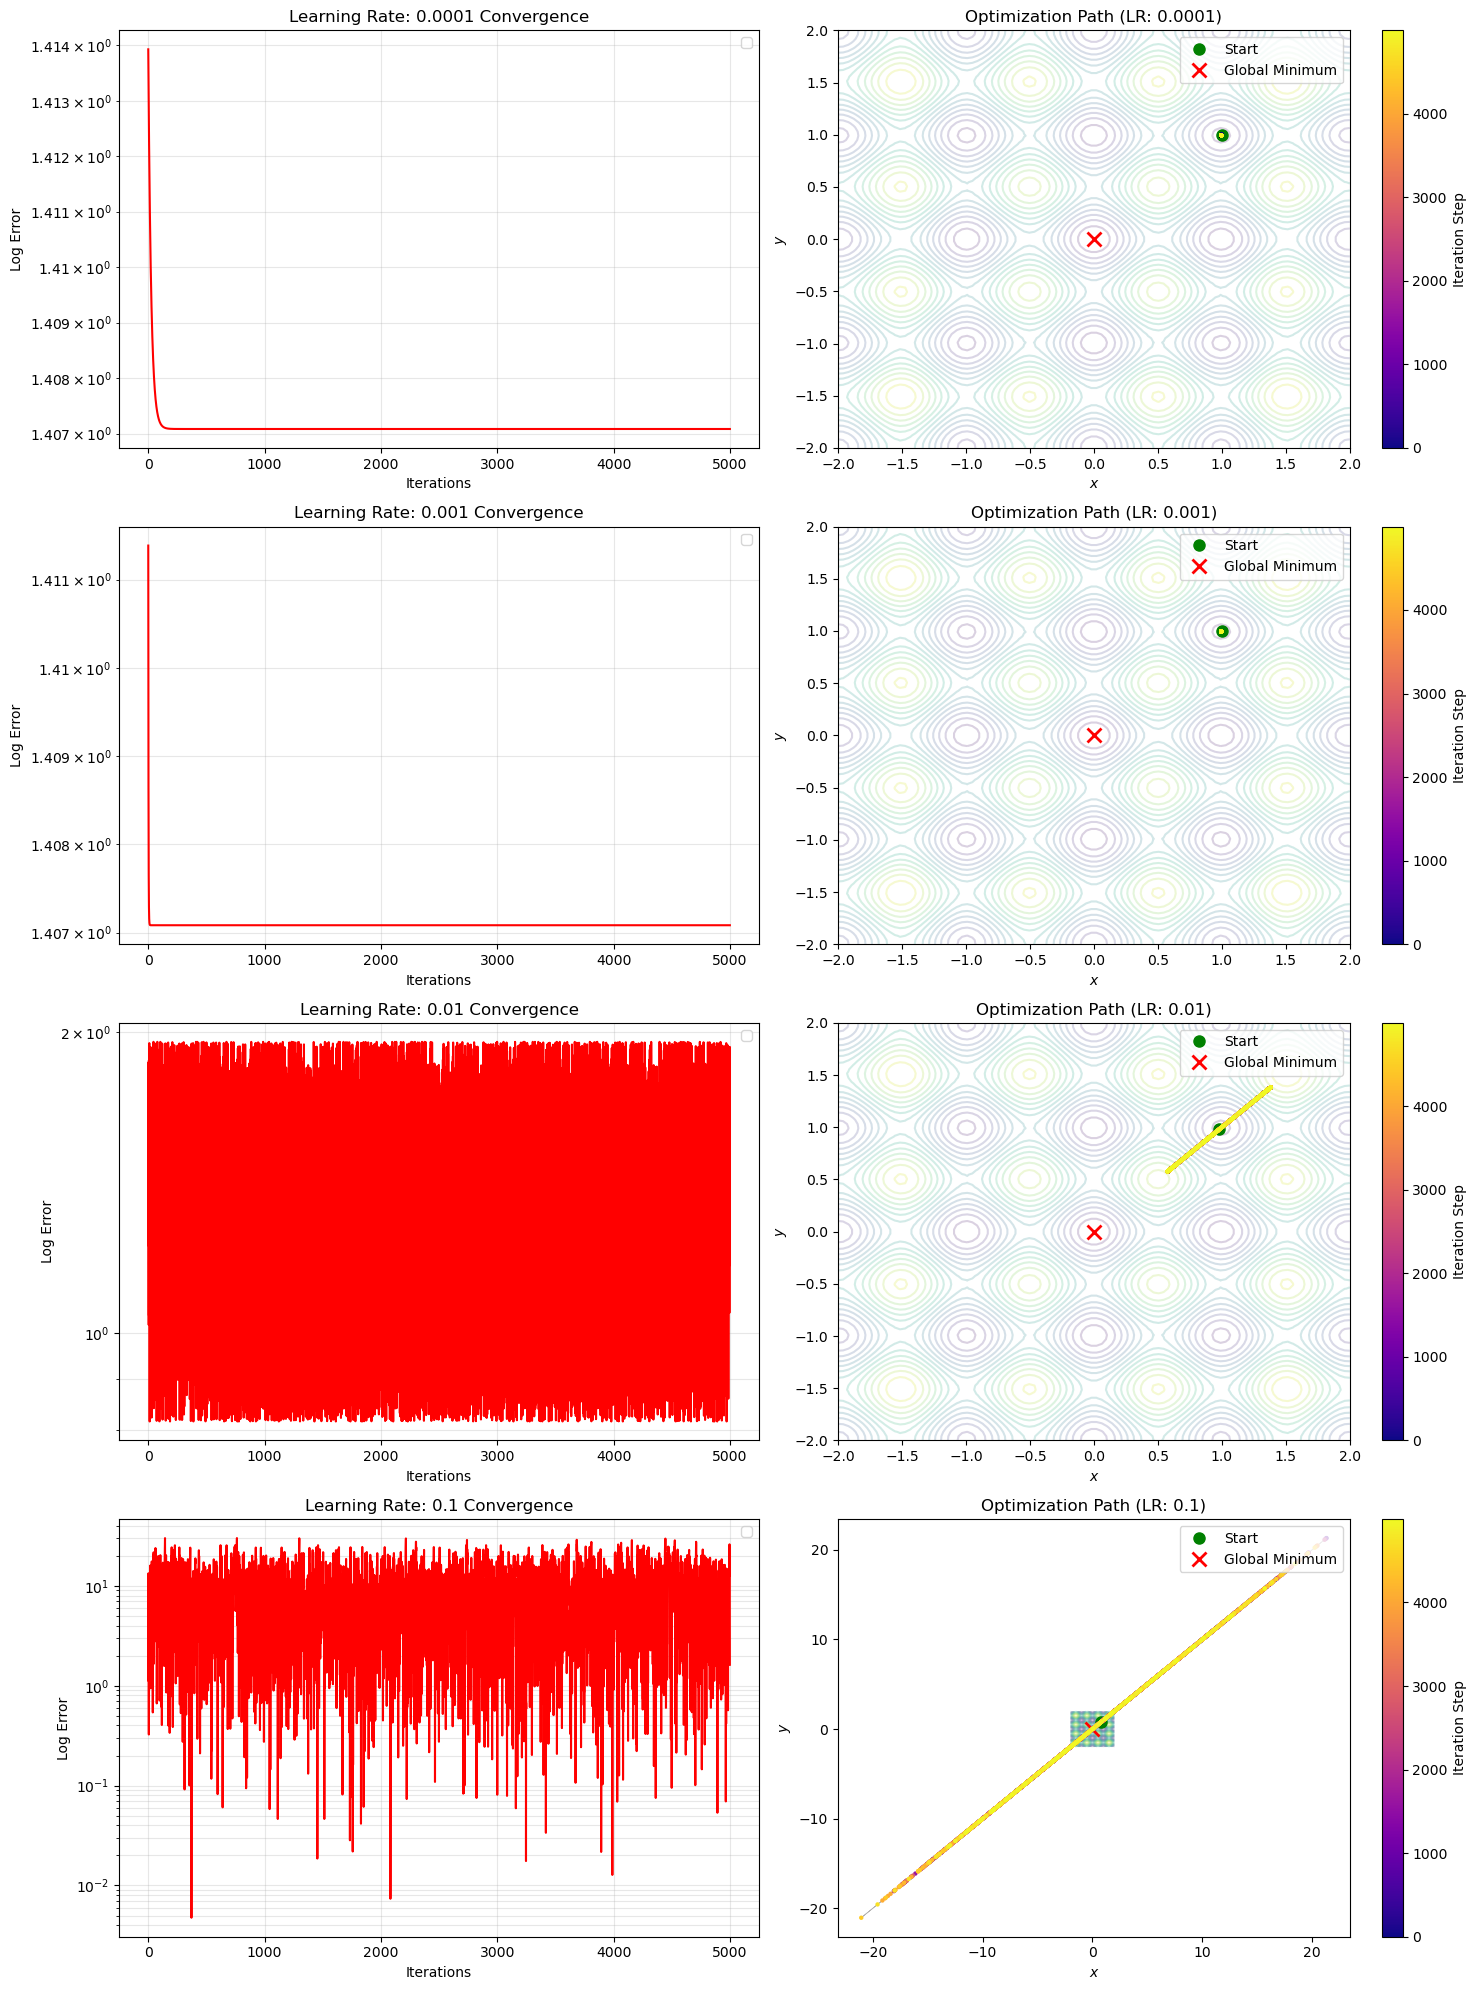

In [9]:
"""
Graphing Log Error Vs Iterations for Different Learning Rates and The Path of the Gradient Descent 
"""
fig, axs = plt.subplots(len(lrs), 2, figsize=(15, 5*len(lrs)))
iterations = range(1,5000)
exact = np.array([0,0])
for i, lr in enumerate(lrs):
    v, errors, path = function_basic_gradient(Rastrigin, gradientRastrigin, exact, [1,1], lr, iterations)
    ax_error = axs[i,0]
    ax_path = axs[i,1]
    # ERROR 
    ax_error.semilogy(range(len(errors)), errors, 'r-')
    ax_error.set_xlabel('Iterations')
    ax_error.set_ylabel('Log Error')
    ax_error.set_title(f'Learning Rate: {lr} Convergence')
    ax_error.grid(True, which="both", ls="-", alpha = 0.3)
    ax_error.legend()

    # PATH PLOT
    path = np.array(path)
    x_range = np.linspace(-2,2,100)
    y_range = np.linspace(-2,2,100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = Rastrigin(X,Y)
    ax_path.contour(X, Y, Z, levels = 15, cmap='viridis', alpha=0.2)
    
    #trajectory line
    ax_path.plot(path[:,0], path[:,1], 'k-', linewidth=0.5, alpha = 0.3) 
    step_indices = np.arange(len(path))
    scatter = ax_path.scatter(path[:,0], path[:,1], c=step_indices, cmap='plasma', s=10, edgecolors='none', zorder=3)
    
    cbar = fig.colorbar(scatter, ax = ax_path)    
    cbar.set_label('Iteration Step')
    ax_path.plot(path[0,0], path[0,1],'go', label='Start', markersize=8)
    ax_path.plot(exact[0],exact[1],'rx', markersize=10, label='Global Minimum', markeredgewidth=2)
    ax_path.set_title(f'Optimization Path (LR: {lr})')
    ax_path.set_xlabel('$x$')
    ax_path.set_ylabel('$y$')
    ax_path.legend(loc='upper right')
plt.tight_layout()
plt.show();

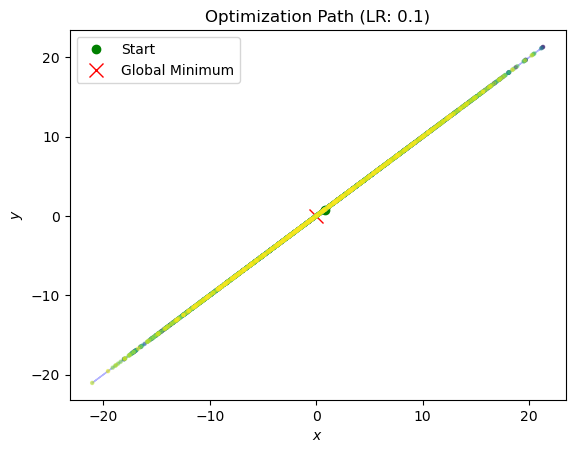

In [10]:
plt.plot(path[:,0], path[:,1], 'b-', linewidth=1, alpha = 0.3) 
step_indices = np.arange(len(path))
scatter = plt.scatter(path[:,0], path[:,1], c=step_indices, cmap='viridis', s=5, zorder=3, alpha=0.5)
plt.plot(path[0,0], path[0,1],'go', label='Start')
plt.plot(exact[0],exact[1],'rx', markersize=10, label='Global Minimum')
plt.title(f'Optimization Path (LR: {lr})')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()

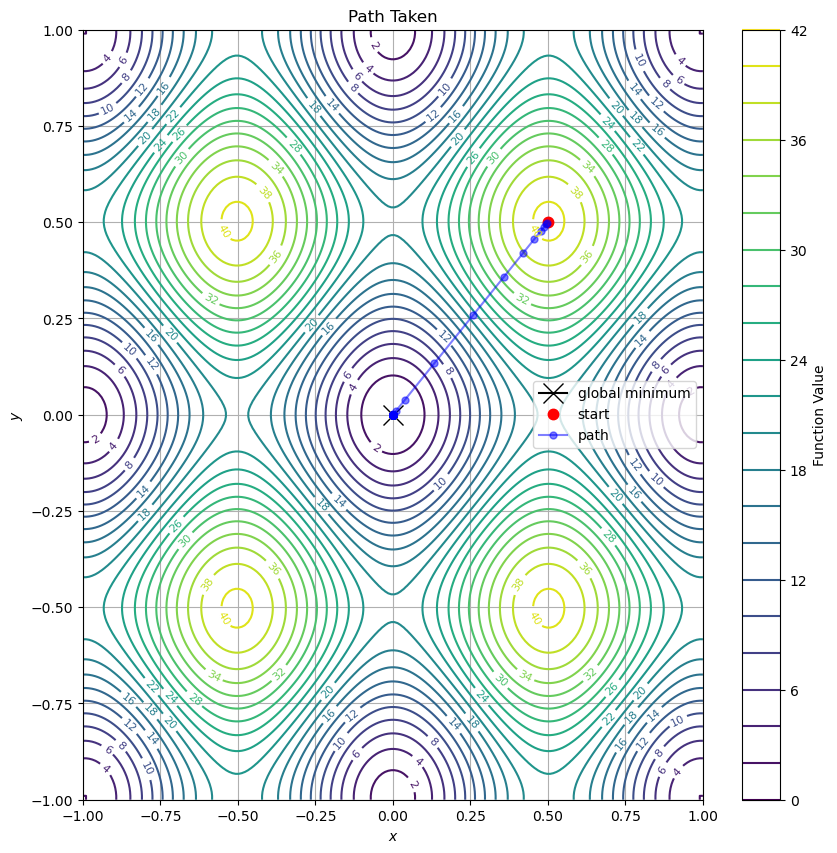

In [11]:
X = np.linspace(-1, 1, 200)
Y = np.linspace(-1,1,200)
X, Y = np.meshgrid(X, Y)
Z = Rastrigin(X, Y)
plt.figure(figsize=(10,10))
exact = [0,0]
contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.plot(0,0, marker='x', markersize= 15, color='black',label='global minimum')
plt.title('Rastrigin')
# Gradient 
#(func, grad, exact, start, learningRate, iterations
start = [0.5,0.5]
iterations = np.arange(1,500)
lr = 0.002
final, errors, path = function_basic_gradient(Rastrigin, gradientRastrigin, exact, start, lr, iterations) 
path = np.array(path)
plt.plot(start[0], start[1], 'r.', markersize=15, label='start')
plt.plot(path[:,0], path[:,1], 'b.-', markersize=10, alpha = 0.5, label='path')
plt.title('Path Taken')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.legend()
plt.colorbar(contour, label='Function Value')
plt.grid(True)

Text(0.5, 1.0, 'Log Error vs. Iterations')

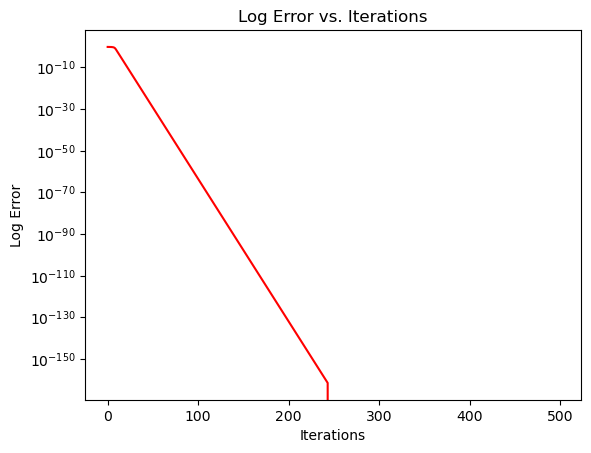

In [13]:
plt.semilogy(range(len(errors)), errors, 'r-')
plt.xlabel('Iterations')
plt.ylabel('Log Error')
plt.title('Log Error vs. Iterations')

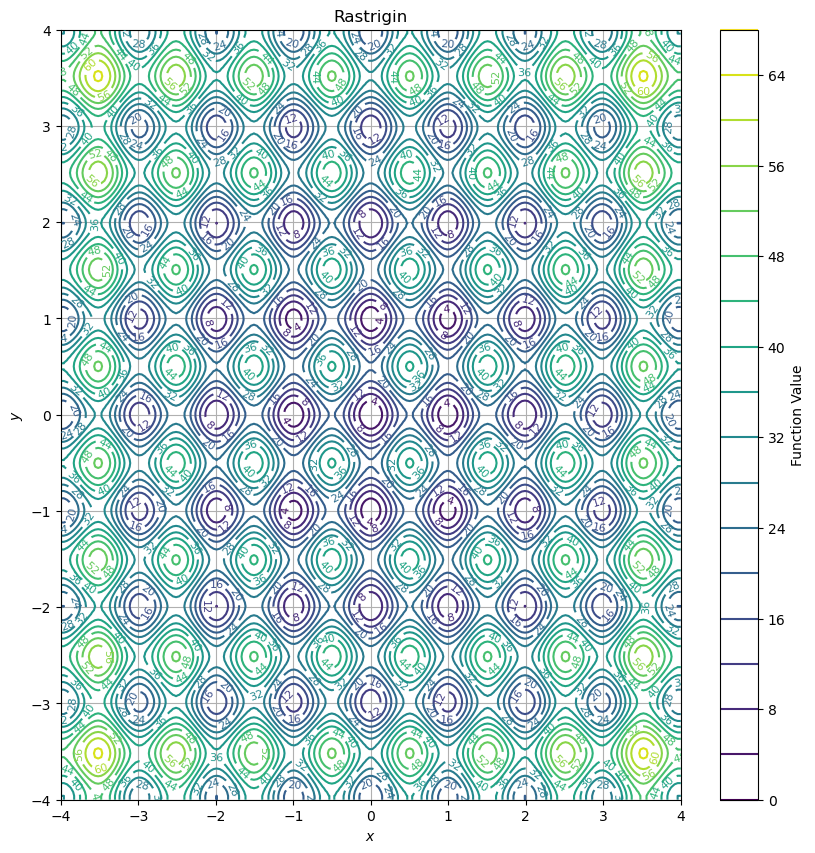

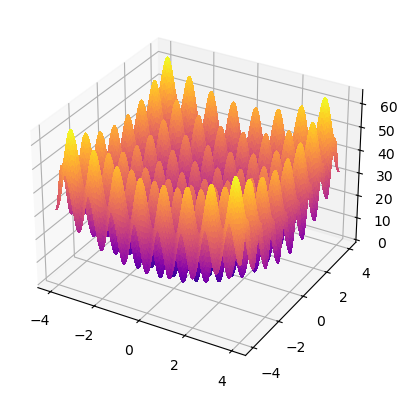

In [12]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
X = np.linspace(-4,4,200)
Y = np.linspace(-4,4,200)
X, Y = np.meshgrid(X, Y)
Z = Rastrigin(X, Y)
plt.figure(figsize=(10,10))

contour = plt.contour(X, Y, Z, 20, cmap='viridis')
plt.clabel(contour, inline = True, fontsize=8)
plt.title('Rastrigin')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.colorbar(contour, label='Function Value')
plt.grid(True)
#fig = plt.figure()
ax = plt.figure().add_subplot(projection='3d')
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.plasma, linewidth=0, antialiased=False)    